**Solving systems of nonlinear equations** We would like to find a solution (or at least an approximate solution) to a system of nonlinear equations. For example
\begin{align*}
	x_1^2 - x_2^2 &= 1, \\
	x_1 + x_2 - x_1x_2 &= 1.
\end{align*}
This system is equivalent to the system
\begin{align*}
	x_1^2 - x_2^2 -1 &= 0, \\
	x_1 + x_2 - x_1x_2 -1 &= 0.
\end{align*}
If we set  $\mathbf{F}(x_1, x_2) = [x_1^2 - x_2^2 -1, x_1 + x_2 - x_1x_2 -1]^\mathsf{T}$, we can rewrite this system as $$\mathbf{F}(\mathbf{x}) = \mathbf{0},$$
where $\mathbf{x} = [x_1, x_2]^\mathsf{T}$. In other words, we are looking for zeros of a vector-valued function of several variables.

Let us formulate a more general problem. Let  $U \subseteq \mathbb{R}^n$ be the domain of a function $\mathbf{F} \colon U \to \mathbb{R}^n$.
The idea is to generalise Newton's method for finding approximations to zeros of a function of a single variable, which suggests that for $f \colon D \to \mathbb{R}$ we pick an initial guess $x^{(0)} \in D$ and then iteratively improve the accuracy of the solution using the recursive formula $$x^{(k+1)} = x^{(k)} - \frac{f(x^{(k)})}{f'(x^{(k)})} \textrm{. }$$

For a vector-valued function $\mathbf{F}(\mathbf{x}) = [F_1(x_1,\ldots,x_n), \ldots, F_n(x_1, \ldots, x_n)]^\mathsf{T}$ we must substitute the derivative $f'$ with the _Jacobian matrix_ of $\mathbf{F}$: $$J \mathbf{F} = \left[\frac{\partial F_i}{\partial x_j}\right]_{ij} \textrm{. }$$
One step of the _Newton's iteration_ is then written as $$\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - (J\mathbf{F})^{-1} \mathbf{F}(\mathbf{x}^{(k)}) \textrm{. }$$

**Task 1** 
Find the approximate solution $[x_1, x_2]^\mathsf{T}$ to the system
\begin{align*}
	x_1^2 - x_2^2 &= 1, \\
	x_1 + x_2 - x_1x_2 &= 1, 
\end{align*} 
which is accurate to 10 decimal places.

Write a _Julia_ function `newton(F, JF, x0; tol = 1e-10, maxit = 100)` which performs Newton's iteration with the initial approximation `x0` for the function `F` and the Jacobian matrix function `JF`. We use the keyword argument `maxit` to limit the maximum number of allowed iterations (in order to avoid a potentially infinite loop), and we use `tol` to prescribe the desired accuracy.

In [101]:
# We'll need the `norm` function from LinearAlgebra
using LinearAlgebra
# the actual `newton` function
function newton(F, JF, X0; tol = 1e-10, maxit = 100)
    #X = newton(F, JF, X0, tol, maxit) solves the (nonlinear) 
    #system F(X) = 0 using the Newton's iteration with initial
    #guess X0. (JF is the Jacobi matrix of F.)
    #X0 previous solution, Xi the next
    # YOUR CODE HERE
    X = [X0]
    Xi = X0;
    k = 0;
    for i in 1:maxit
        J = JF(X0)
        Xi = X0 - J\F(X0)
        push!(X, Xi)
        k = i
        if norm(Xi - X0) < tol
            return (X = X, k)
        end
        X0 = Xi
    end
    return (X = X, k = n)
end

newton (generic function with 1 method)

In [102]:
# the function F and its Jacobian matrix JF from Task 1
F(X) = [X[1]^2 - X[2]^2 - 1; X[1] + X[2] - X[1]*X[2] - 1]
JF(X) = [2*X[1] -2*X[2]; 1-X[2] 1-X[1]]# YOUR CODE HERE
rez = newton(F, JF, [0.4;0.5]; maxit = 500)
#e1 = rez[1]^2 - rez[2]^2 - 1
#e2 = rez[1] + rez[2] - rez[1]*rez[2] - 1
#println("norma rezultata: ", norm(rez .- 1))

(X = [[0.4, 0.5], [1.373469387755102, 0.1887755102040818], [1.090881863262985, 0.38618283614417215], [0.9481361081472117, 0.035893506011457854], [1.00123136364954, 0.013003482749172374], [0.9999909460494675, 0.00574631087598602], [1.000000026122421, 0.002877694210429862], [0.999999999962305, 0.0014388340060531783], [1.0000000000000273, 0.0007194170219278721], [1.0, 0.0003597085109514577]  …  [1.0, 1.405109758410191e-6], [1.0000000000000002, 7.026423718027665e-7], [1.0, 3.5131415752774423e-7], [1.0, 1.7560703372848812e-7], [1.0, 8.77284350491792e-8], [1.0000000000000002, 4.5333433694492917e-8], [1.0, 2.206778177556311e-8], [1.0, 1.2005845909815435e-8], [1.0, 7.382169107011025e-9], [1.0, 7.382169107011025e-9]], k = 26)

**Task 2**
Let $f$ be a function of two variables, $x$ and $y$. We would like to find a sequence of equidistant points (according to the Euclidean distance) on the curve defined by $$f(x,y) = 0 \textrm{. }$$

Denote the given distance between two successive points by $\delta$. Assume that the first point  $(x_0, y_0)$ is given. The next point, say $(x,y)$, is determined by the conditions that the distance from  $(x_0, y_0)$ equals $\delta$, and that it lies on the curve $f(x,y)=0$. This means that $(x,y)$ should solve the system of equations 
\begin{align*}
	f(x,y) &= 0 \textrm{, }\\
	(x-x_0)^2 + (y-y_0)^2 &= \delta^2 \textrm{. }
\end{align*} 
The next point is therefore obtained as a solution to this system, and we denote this solution  by $(x_1, y_1)$. We repeat the procedure to obtain the next point $(x_2, y_2)$ and so on.

Write a _Julia_ function `K = curve(f, gradf, T0, delta, n)` that returns the vector of 2-tuples `K` containing the sequence of points on the curve $f(x,y) = 0$, with mutual distances $\delta$. (`f` is the given function of two variables and `gradf` is its gradient, `T0` is the initial point).

In [107]:
function curve(f, gradf, T0, delta, n)
    # first, a correction to T0  - to obtain a point on the curve
    g = gradf(T0...)
    ng = [-g[2]; g[1]]
    # define the function (and its Jacobi matrix) 
    # for the system which will give us the correction to T0
    F(X) = [f(X...); ng'*(X - collect(T0))]
    JF(X) = [gradf(X...)'; ng']
    # define an empty vector of 2-tuples
    K = Tuple{Float64, Float64}[]
    # add the first point (the correction to T0) to that vector
    push!(K, Tuple(newton(F, JF, collect(T0)).X[end]))

    # obtaining succesive points on the curve
    for k in 2:n
        # define the function (and its Jacobi matrix) 
        local F(X) = [f(X...); (X - collect(K[end]))'*(X - collect(K[end])) - delta^2]
        local JF(X) = [gradf(X...)'; 2*(X - collect(K[end]))']
        # determine the tangent through the current point
        g = gradf(K[end]...)
        ng = [-g[2]; g[1]]
        # evaluate the next point and add it to K
        push!(K, Tuple(newton(F, JF, collect(K[end]) + delta*ng/norm(ng)).X[end]))
        # break the loop once close enough to the starting point (in case of a closed curve)
        if(norm(collect(K[end]) - collect(K[1])) < delta/2)
            break;
        end
    end

    return K
end

curve (generic function with 1 method)

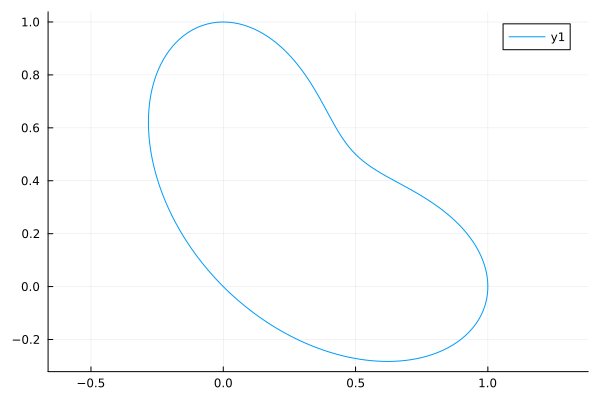

In [108]:
# plot the curve given by
f(x, y) = (x^2+y^2)^2 - x^3 - y^3
gradf(x, y) = [4*x*(x^2+y^2) - 3*x^2; 4*y*(x^2+y^2) - 3*y^2]
K = curve(f, gradf, (1.0,0.0), 0.02, 200)
using Plots
plot(K; ratio = 1)

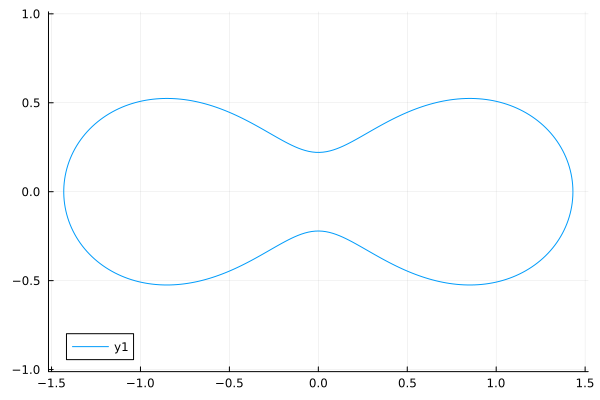

In [109]:
# plot the curve given by
f(x, y) = (x^2+y^2)^2 - 2*(x^2-y^2)-0.1
gradf(x, y) = [4*x*(x^2+y^2) - 4*x; 4*y*(x^2+y^2) + 4*y]
K = curve(f, gradf, (1.4, 0), 0.02, 500)
using Plots
plot(K; ratio = 1)